<a href="https://colab.research.google.com/github/naumovakotya/My_projects_DS/blob/Stock_prediction/Order_analysis_dwh_test_task/tt_m1_ds_NaumovaE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Junior Data Scientist / Аналитик  - тестовое задание, 2025
[Вакансия](https://hh.ru/vacancy/117152095)

[ТЗ](https://docs.google.com/document/d/1nqMm0QaTJG1lZ1GvEwiDOGO-KxCGileZUov_x4MFoHQ/edit?usp=sharing)

[Резюме](https://drive.google.com/file/d/1-q8V0Ki92j4nMedOAeTOiAMnajcWBRzX/view?usp=sharing)

Выполнила: **Наумова Екатерина**


Каналы связи со мной:
<div id="badges" style="display: flex; gap: 10px;">
  <a href="https://t.me/Naumova_E">
    <img src="https://img.shields.io/badge/Telegram-229ED9?style=for-the-badge&logo=telegram&logoColor=white" alt="Telegram Badge"/>
  <a href="https://www.linkedin.com/in/naumova-kotya/">
    <img src="https://img.shields.io/badge/LinkedIn-blue?style=for-the-badge&logo=linkedin&logoColor=white" alt="LinkedIn Badge"/>
  <a href="https://github.com/naumovakotya">
    <img src="https://img.shields.io/badge/GitHub-black?style=for-the-badge&logo=GitHub&logoColor=white" alt="GitGub Badge"/>
  <a href="mailto:naumova.ea.1@gmail.com">
    <img src="https://img.shields.io/badge/Gmail-red?style=for-the-badge&logo=gmail&logoColor=white" alt="Gmail Badge"/>
  <a href="https://www.facebook.com/profile.php?id=100022394204077">
    <img src="https://img.shields.io/badge/Facebook-blue?style=for-the-badge&logo=Facebook&logoColor=white" alt="Facebook Badge"/>
</div>

## Задание 1: SQL запросы

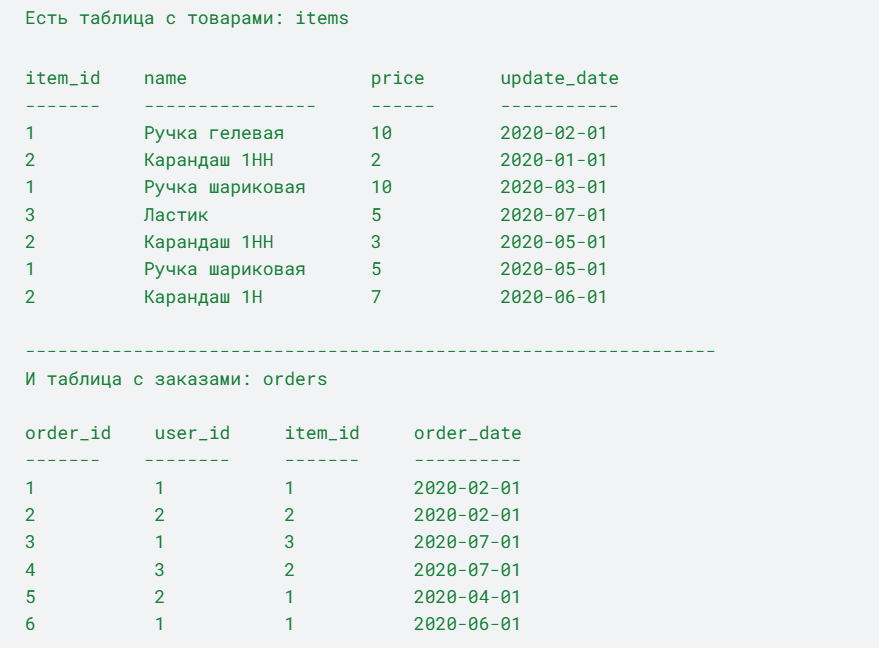

### 1. Вывести актуальное состояние товаров на 2020-06-01

#### Подготовка к выполнению задания

Однако прежде, чем перейти к заданию, настроим PostgeSQL и создадим предложенные таблицы.

In [ ]:
# !apt-get -qq update
# !apt-get -qq install postgresql postgresql-contrib
# !service postgresql start
# !sudo -u postgres psql -c "ALTER USER postgres PASSWORD 'password';"

In [ ]:
# !pip install psycopg2-binary

После того, как к PostgreSQL успешно настроен и запущен, перейдём к подключению  к бд.

In [ ]:
# загрузка необходимых библиотек
import psycopg2
import pandas as pd
from IPython.display import display

In [ ]:
conn = psycopg2.connect(
    dbname="postgres",
    user="postgres",
    password="password",
    host="localhost",
    port="5432"
)

cur = conn.cursor()

In [ ]:
# Создаём таблицы items и orders, добавляем тестовые данные
cur.execute("""
CREATE TABLE IF NOT EXISTS items (
    item_id INT,
    name TEXT,
    price DECIMAL(10,2),
    update_date DATE
);
""")

cur.execute("""
CREATE TABLE IF NOT EXISTS orders (
    order_id INT,
    user_id INT,
    item_id INT,
    order_date DATE
);
""")

cur.executemany("""
INSERT INTO items (item_id, name, price, update_date) VALUES (%s, %s, %s, %s);
""", [
    (1, "Ручка гелевая", 10, "2020-02-01"),
    (2, "Карандаш 1HH", 2, "2020-01-01"),
    (1, "Ручка шариковая", 10, "2020-03-01"),
    (3, "Ластик", 5, "2020-07-01"),
    (2, "Карандаш 1HH", 3, "2020-05-01"),
    (1, "Ручка шариковая", 5, "2020-05-01"),
    (2, "Карандаш 1H", 7, "2020-06-01")
])

cur.executemany("""
INSERT INTO orders (order_id, user_id, item_id, order_date) VALUES (%s, %s, %s, %s);
""", [
    (1, 1, 1, "2020-02-01"),
    (2, 2, 2, "2020-02-01"),
    (3, 1, 3, "2020-07-01"),
    (4, 3, 2, "2020-07-01"),
    (5, 2, 1, "2020-04-01"),
    (6, 1, 1, "2020-06-01")
])

conn.commit()

In [ ]:
# Функция для выполнения SQL-запроса и вывода результатов в виде таблицы

def execute_query(conn, query, columns):
    """Выполняет SQL-запрос и выводит результат в виде таблицы."""
    try:
        # Открываем соединение с БД и создаём курсор
        with conn.cursor() as cur:
            cur.execute(query)  # Выполняем SQL-запрос
            rows = cur.fetchall()  # Получаем результаты
            df = pd.DataFrame(rows, columns=columns)  # Создаём DataFrame

            display(df)  # Красиво выводим таблицу
    except Exception as e:
        print(f"Ошибка выполнения запроса: {e}")
    finally:
        # Закрываем соединение
        conn.commit()  # Фиксируем изменения (если были)

#### Допущения к данным

Мы можем заметить несколько особенностей в данных, которые необходимо рассмотреть подробнее прежде чем переходить к выполнению запросов.

 **🚀 1. Проблема с `item_id` в таблице `items`**

В текущей таблице `items` **`item_id` не является уникальным идентификатором товара**, потому что:  
- Название товара может изменяться (например, `Ручка гелевая` → `Ручка шариковая`).  
- Один `item_id` может означать разные товары в разное время.  

**Пример**:  

| item_id | name             | price | update_date |
|---------|-----------------|-------|------------|
| 1       | Ручка гелевая   | 10.00 | 2020-02-01 |
| 1       | Ручка шариковая | 10.00 | 2020-03-01 |

Здесь **`item_id = 1` сначала был "Ручка гелевая", потом "Ручка шариковая"**.  
Это **может привести к путанице** при анализе данных. И такой пример не единственный, к сожалению.

---

**🚀 Возможные причины проблемы**
1. **Ошибка в данных** – возможно, изначально товары не должны были менять названия.  
2. **Логика системы** – возможно, `item_id` используется не как уникальный товар, а как группа товаров.  
3. **Нет строгого контроля за изменением названий** – если в базе **не отслеживаются изменения названий**, это может приводить к такой ситуации.

---

**🚀 Решение на будущее**

Чтобы избежать этой проблемы, можно:
1. **Ввести новый `unique_id` на основе `item_id` и порядкового номера (например, `1_item1`, `1_item2`):**
   ```sql
   UPDATE items
   SET unique_id = CONCAT(item_id, '_item', ROW_NUMBER() OVER (PARTITION BY item_id ORDER BY update_date));
   ```
 Теперь товары **получат разные `unique_id`, даже если `item_id` одинаковый**.

2. **Разделить товары на отдельные `item_id`, если это действительно разные вещи.**  
   - Например, создать **новые `item_id`** для гелевых и шариковых ручек.

3. **Добавить таблицу версий названий товаров**, где хранить **историю изменений `name`**.

---

Однако, в данном случае мы придерживаемся версии, что **`item_id` является уникальным индетификатором товара**. Однако, в именах товаров имеются ошибки либо они были изменены. Мы трактуем, что `item_id` = 1 – это один и тот же товар, просто изменилось название.

**🚀2. Улучшения на будущее: Индексы**

В данных запросах **не создаются индексы на таблицах**, потому что предполагается, что объём данных невелик, и SQL-запросы выполняются достаточно быстро без дополнительной оптимизации. Однако, в реальных системах при большом объёме данных индексы на `item_id`, `update_date` и `order_date` могли бы значительно ускорить запросы.

🚀 **Пример индекса, который можно создать в проде:**

   ```sql
   CREATE INDEX idx_items ON items (item_id, update_date DESC);
   ```



#### Переходим непосредственно к выполнению задания

In [ ]:
# Запрос
query_1 = """
SELECT DISTINCT ON (item_id)
    item_id, name, price, update_date
FROM items
WHERE update_date <= '2020-06-01'
ORDER BY item_id, update_date DESC;
"""

columns_1=['Уникальный номер товара', 'Наименование товара', 'Стоимость', 'Дата обновления']
execute_query(conn, query_1, columns_1)

,Уникальный номер товара,Наименование товара,Стоимость,Дата обновления
0,1,Ручка шариковая,5.00,2020-05-01
1,2,Карандаш 1H,7.00,2020-06-01


### 2. Товары, купленные по цене больше или равно чем 3

In [ ]:
query_2 = """
SELECT DISTINCT o.order_id, i.*, o.order_date
FROM orders o
JOIN LATERAL (
    SELECT i.name, i.price
    FROM items i
    WHERE i.item_id = o.item_id AND i.update_date <= o.order_date
    ORDER BY i.update_date DESC
    LIMIT 1
) i ON true
WHERE i.price >= 3
"""
columns_2=["Уникальный номер транзакции", "Наименование товара", "Стоимость", "Дата транзакции"]
execute_query(conn, query_2, columns_2)


,Уникальный номер транзакции,Наименование товара,Стоимость,Дата транзакции
0,1,Ручка гелевая,10.00,2020-02-01
1,3,Ластик,5.00,2020-07-01
2,4,Карандаш 1H,7.00,2020-07-01
3,5,Ручка шариковая,10.00,2020-04-01
4,6,Ручка шариковая,5.00,2020-06-01


### 3. Сумму покупок клиента 1


In [ ]:
query_3 = """
SELECT o.user_id, SUM(i.price) AS total_spent
FROM orders o
LEFT JOIN LATERAL (
    SELECT i.price
    FROM items i
    WHERE i.item_id = o.item_id AND i.update_date <= o.order_date
    ORDER BY i.update_date DESC
    LIMIT 1
) i ON true
WHERE o.user_id = 1
GROUP BY o.user_id;
"""

execute_query(conn, query_3, ["Уникальный номер клиента", "Сумма покупок"])

,Уникальный номер клиента,Сумма покупок
0,1,20.00


### 4. Сумма всех покупок до 2020-05-01 включительно


In [ ]:
query_4 = """
SELECT SUM(i.price) AS total_sales
FROM orders o
LEFT JOIN LATERAL (
    SELECT i.price
    FROM items i
    WHERE i.item_id = o.item_id AND i.update_date <= o.order_date
    ORDER BY i.update_date DESC
    LIMIT 1
) i ON true
WHERE o.order_date <= '2020-05-01';
"""

execute_query(conn, query_4, ["Сумма всех покупок до 2020-05-01"])


,Сумма всех покупок до 2020-05-01
0,22.00


### 5. Сумму всех заказов и среднее цена заказа поквартально


In [ ]:
query_5 = """
SELECT
    TO_CHAR(DATE_TRUNC('quarter', o.order_date), 'YYYY "Q"Q') AS quarter,
    SUM(i.price) AS total_sales,
    ROUND(AVG(i.price), 2) AS avg_order_price
FROM orders o
LEFT JOIN LATERAL (
    SELECT i.price
    FROM items i
    WHERE i.item_id = o.item_id AND i.update_date <= o.order_date
    ORDER BY i.update_date DESC
    LIMIT 1
) i ON true
GROUP BY quarter
ORDER BY quarter;
"""

execute_query(conn, query_5, ["Квартал", "Сумма заказов", "Средняя цена заказа"])


,Квартал,Сумма заказов,Средняя цена заказа
0,2020 Q1,12.00,6.00
1,2020 Q2,15.00,7.50
2,2020 Q3,12.00,6.00


### 6. Объясните, как вы будете оптимизировать запросы для больших объемов данных.

Оптимизация запросов для больших объёмов данных включает несколько ключевых стратегий.  

**1. 🚀 Использование индексов**

Использование индексов на часто используемых полях (`item_id`, `update_date`, `order_date`) позволяет ускорить `JOIN` и фильтрацию, сокращая время выполнения запросов.

Например:  
```sql
CREATE INDEX idx_items ON items (item_id, update_date DESC);
CREATE INDEX idx_orders ON orders (item_id, order_date);
```
---
**2. 🚀 Партиционирование таблиц**

Партиционирование таблиц снижает нагрузку на сервер, позволяя работать только с нужным диапазоном данных, а не со всей таблицей.

Например, для заказов можно создать партиции по годам:  
```sql
CREATE TABLE orders_2020 PARTITION OF orders
FOR VALUES FROM ('2020-01-01') TO ('2020-12-31');
```
---
**3. 🚀 Предварительный расчёт агрегированных данных**

Для аналитических запросов эффективным решением будет предварительный расчёт агрегированных данных с использованием `MATERIALIZED VIEW`. Это позволяет хранить уже рассчитанные значения и обновлять их только при изменениях:  
```sql
CREATE MATERIALIZED VIEW mv_quarterly_sales AS
SELECT TO_CHAR(DATE_TRUNC('quarter', o.order_date), 'YYYY "Q"Q') AS quarter,
       SUM(i.price) AS total_sales,
       ROUND(AVG(i.price), 2) AS avg_order_price
FROM orders o
JOIN items i ON o.item_id = i.item_id
GROUP BY quarter;
```
Обновление выполняется по необходимости:  
```sql
REFRESH MATERIALIZED VIEW mv_quarterly_sales;
```
---
**4. 🚀 Оптимизация SQL-запросов**

Оптимизация SQL-запросов позволяет ускорить их выполнение и снизить нагрузку на базу данных.  

Во-первых, важно выбирать только необходимые столбцы вместо `SELECT *`, что уменьшает объем передаваемых данных.

Например:  
```sql
SELECT o.order_id, i.price
FROM orders o
JOIN items i ON o.item_id = i.item_id;
```  

Во-вторых, фильтрацию строк стоит проводить **до соединения таблиц**, чтобы уменьшить количество обрабатываемых данных. Вместо  
```sql
SELECT o.user_id, SUM(i.price)
FROM orders o
JOIN items i ON o.item_id = i.item_id
WHERE o.order_date >= '2023-01-01'
GROUP BY o.user_id;
```
лучше предварительно отфильтровать заказы:  
```sql
SELECT o.user_id, SUM(i.price)
FROM (SELECT * FROM orders WHERE order_date >= '2023-01-01') o
JOIN items i ON o.item_id = i.item_id
GROUP BY o.user_id;
```  

Для агрегатных функций, таких как `SUM` и `COUNT`, лучше заранее группировать данные перед `JOIN`, чтобы сократить количество строк.  
```sql
WITH aggregated_orders AS (
    SELECT user_id, item_id, COUNT(*) AS order_count
    FROM orders
    GROUP BY user_id, item_id
)
SELECT a.user_id, SUM(i.price * a.order_count)
FROM aggregated_orders a
JOIN items i ON a.item_id = i.item_id
GROUP BY a.user_id;
```  

Дополнительно полезно анализировать выполнение запросов с помощью `EXPLAIN ANALYZE`, чтобы выявлять узкие места и корректировать стратегию индексации. Такой подход снижает нагрузку на базу и ускоряет обработку данных даже без изменений в её структуре.

---
**5. 🚀 Кэширование**

Дополнительно, если аналитика требует частого пересчёта одних и тех же данных, можно использовать кэширование в Redis. Это позволяет хранить результаты SQL-запросов в памяти, снижая нагрузку на базу.  

---
Выбор конкретных методов зависит от структуры данных, нагрузки на систему и требований к производительности. В реальных проектах эти подходы применяются комплексно, чтобы обеспечить баланс между быстродействием и ресурсопотреблением.

## Задание 2:

У нас есть поток заказов, примерно 100 000 заказов в день, которые записываются в таблицу `orders`.  
Эти данные переливаются в DWH, но есть сложность:

- В первые 6 месяцев заказы активно изменяются (например, обновляется статус, состав заказа, стоимость и т. д.).
- Далее в течение 2-5 лет возможны редкие изменения.
- Мы не можем использовать метку времени обновления (`updated_at` или аналоги).

Вопросы не подразумевают единственно верного варианта решения задачи.
Ожидаем, что вы изложите ход мысли и подробно опишете решения, ответив на следующие вопросы:



### 1. Как можно построить архитектуру DWH на основе Data Vault 2.0, чтобы:
    - Обеспечить актуальность данных (иметь "актуальную" таблицу заказов).
    - Эффективно хранить изменения, учитывая разные паттерны обновлений.
    - Не терять историчность (возможность "путешествовать" во времени).

Для эффективного хранения данных о заказах, их изменений и возможности восстановления истории можно использовать **Data Vault 2.0**, разделяя данные на **Hub, Link и Satellite**.  

**1. 🌍 Выделение сущностей и их роль**  
1. **Hub** (основная сущность): содержит *уникальные идентификаторы заказов* (`order_id`). Эта таблица неизменяема.  
2. **Link** (связи): связывает заказы с клиентами, товарами и статусами.  
3. **Satellite** (история изменений): содержит изменяемые атрибуты заказа (статус, состав, стоимость) и *флаг актуальности*, позволяющий определять последнюю версию записи.  

Пример структуры:  
```sql
CREATE TABLE hub_orders (
    order_id BIGINT PRIMARY KEY,
    load_date TIMESTAMP DEFAULT NOW()
);

CREATE TABLE link_orders_customers (
    order_id BIGINT REFERENCES hub_orders(order_id),
    customer_id BIGINT,
    load_date TIMESTAMP DEFAULT NOW()
);

CREATE TABLE sat_orders (
    order_id BIGINT REFERENCES hub_orders(order_id),
    status TEXT,
    total_price DECIMAL(10,2),
    hash_value TEXT,
    load_date TIMESTAMP DEFAULT NOW(),
    is_active BOOLEAN DEFAULT TRUE
);
```
---

**2. 🌍 Обновление актуального состояния без `updated_at`**  
Так как `updated_at` недоступен, можно определять изменения через **хеши строк**:  

1. **Генерация хеша** на основе всех атрибутов заказа (`status`, `total_price`).  
2. **Сравнение нового хеша с последней записью**:  
   - Если хеш *не изменился*, запись *не создаётся*.  
   - Если изменился, создаётся *новая запись*, а старая помечается `is_active = FALSE`.  

```sql
SELECT *
FROM sat_orders
WHERE is_active = TRUE;
```
Этот метод позволяет *обновлять заказы без временных меток* и при этом сохранять их историю.  

---

**3. 🌍 Оптимизация работы с данными**  
1. **Партиционирование** таблицы `sat_orders` по `load_date` позволяет ускорить выборки:  
   ```sql
   CREATE TABLE sat_orders PARTITION BY RANGE (load_date);
   ```
2. **Индексы на активные записи** ускоряют доступ к актуальным заказам:  
   ```sql
   CREATE INDEX idx_active_orders ON sat_orders (order_id) WHERE is_active = TRUE;
   ```
3. **Автоматическое архивирование** устаревших данных снижает нагрузку на основную таблицу.  

Такой подход позволяет **эффективно управлять изменяющимися заказами, обеспечивать актуальность данных и сохранять историю изменений** без использования `updated_at`.

### 2. Какие сущности вы выделите и какую роль они будут играть?

В **Data Vault 2.0** сущности делятся на три типа: **Hub** (центры данных), **Link** (связи) и **Satellite** (атрибуты и история изменений).

**1. 🌍 Основные сущности:**
1. **Hub** (основные ключи):  
   - `hub_orders` – идентификатор заказа (`order_id`).  
   - `hub_customers` – уникальный идентификатор клиента (`customer_id`).  
   - `hub_products` – уникальный идентификатор товара (`product_id`).  

2. **Link** (связи между сущностями):
   - `link_orders_customers` – связь между заказами и клиентами.  
   - `link_orders_products` – связь между заказами и товарами.  
   - `link_orders_payments` – связь заказов с оплатами.  

3. **Satellite** (атрибуты и история изменений):  
   - `sat_orders` – хранит изменяемые атрибуты заказа (статус, сумму, метод оплаты).  
   - `sat_customers` – информация о клиентах (имя, адрес, сегмент).  
   - `sat_products` – исторические данные о товарах (цена, категория).  

---

**2. 🌍 Роль каждой сущности**  
- **Hub:** содержит *только неизменяемые идентификаторы* и позволяет масштабировать систему без дублирования данных.  
- **Link:** фиксирует *отношения между сущностями* (например, какие товары входят в заказ).  
- **Satellite:** хранит *изменяемые атрибуты* и позволяет отслеживать их историю.  

Пример структуры **hub_orders**:  
```sql
CREATE TABLE hub_orders (
    order_id BIGINT PRIMARY KEY,
    load_date TIMESTAMP DEFAULT NOW()
);
```
Пример структуры **sat_orders**:  
```sql
CREATE TABLE sat_orders (
    order_id BIGINT REFERENCES hub_orders(order_id),
    status TEXT,
    total_price DECIMAL(10,2),
    hash_value TEXT,
    load_date TIMESTAMP DEFAULT NOW(),
    is_active BOOLEAN DEFAULT TRUE
);
```
Такое разделение обеспечивает **масштабируемость, гибкость в хранении истории изменений и быстрый доступ к актуальным данным**.

### 3. Как можно обновлять актуальное состояние заказов без использования `updated_at`?
  

Так как `updated_at` недоступен, для определения актуальной версии заказа можно использовать **механизм хеширования и флаг актуальности**.  

**1. 🌍 Использование хешей для отслеживания изменений**  
- При поступлении нового заказа *генерируется хеш* на основе его изменяемых атрибутов (`status`, `total_price`).  
- Если *хеш не изменился* по сравнению с последней версией заказа, новая запись *не создаётся*.  
- Если *значение изменилось*, создаётся новая запись, а старая помечается `is_active = FALSE`.  

Пример структуры:  
```sql
CREATE TABLE sat_orders (
    order_id BIGINT REFERENCES hub_orders(order_id),
    status TEXT,
    total_price DECIMAL(10,2),
    hash_value TEXT,
    load_date TIMESTAMP DEFAULT NOW(),
    is_active BOOLEAN DEFAULT TRUE
);
```
Для вычисления хеша можно использовать `MD5`:  
```sql
SELECT MD5(CONCAT(status, total_price)) AS new_hash;
```

При обновлении заказа:  
```sql
UPDATE sat_orders
SET is_active = FALSE
WHERE order_id = NEW.order_id AND hash_value != NEW.hash_value;
```
Затем вставляется новая версия заказа.

---

**2. 🌍 Определение актуальных записей через `is_active`**  
Для получения только последней версии заказа используется:  
```sql
SELECT *
FROM sat_orders
WHERE is_active = TRUE;
```

---

**3. 🌍  Оптимизация за счёт индексов и партиционирования**  
- *Индекс на активные заказы* ускоряет выборку:  
  ```sql
  CREATE INDEX idx_active_orders ON sat_orders (order_id) WHERE is_active = TRUE;
  ```
- *Партиционирование по `load_date`* позволяет эффективно хранить данные:  
  ```sql
  CREATE TABLE sat_orders PARTITION BY RANGE (load_date);
  ```

Этот подход позволяет **обновлять данные без `updated_at`, гарантируя актуальность заказов и сохранение их истории**.

### 4. Как можно оптимизировать работу с данными такого рода?

При работе с **большим количеством заказов и их изменениями** важно учитывать высокую нагрузку на базу данных и эффективно организовать хранение данных. Оптимизация может включать несколько ключевых подходов.

**1. 🌍 Индексы на ключевые столбцы**  
- *Поиск актуальных записей* можно ускорить с помощью индекса:  
  ```sql
  CREATE INDEX idx_active_orders ON sat_orders (order_id) WHERE is_active = TRUE;
  ```
- *Индексация связей между заказами и клиентами* помогает ускорить соединения:  
  ```sql
  CREATE INDEX idx_orders_customers ON link_orders_customers (order_id, customer_id);
  ```
---
**2. 🌍 Партиционирование таблицы `sat_orders`**  
Так как в первые 6 месяцев заказы часто меняются, а затем обновления становятся редкими, *партиционирование по времени загрузки (`load_date`)* поможет ускорить запросы:  
```sql
CREATE TABLE sat_orders PARTITION BY RANGE (load_date);
```
Актуальные данные хранятся в *основной партиции*, а устаревшие перемещаются в архивные.

---

**3. 🌍 Материализованные представления для актуальных данных**  
Вместо выполнения сложного запроса на актуальные заказы каждый раз можно *предрассчитывать результат и хранить его в `MATERIALIZED VIEW`*:  
```sql
CREATE MATERIALIZED VIEW mv_active_orders AS
SELECT * FROM sat_orders WHERE is_active = TRUE;
```
Обновлять представление можно раз в день или при поступлении новых данных:  
```sql
REFRESH MATERIALIZED VIEW mv_active_orders;
```
---

**4. 🌍 Сжатие и дедупликация данных**  
- *Удаление дубликатов* путём проверки хеша заказа (`hash_value`).  
- *Использование `ZSTD` или `lz4`-сжатия* в хранилище для уменьшения объёма исторических данных.

---

**5. 🌍 Разделение потоков данных**  
- *Горячие данные* (последние 6 месяцев) хранятся в быстрых `OLTP`-таблицах.  
- *Холодные данные* (история) переносятся в *DWH или S3-хранилища* для аналитики.  

Эти методы позволяют **ускорить работу с заказами, снизить нагрузку на базу и эффективно управлять историческими изменениями**.